# Data exploration
Data exploratin of the final dataset: 
- day, pos, number of vessel, bgc variables 

# Set

In [2]:
import numpy as np
import pandas as pd
import sklearn

print("Notebook AIPS check")
print(np.__version__)
print(pd.__version__)
print(sklearn.__version__)

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Notebook AIPS check
2.2.6
2.3.3
1.7.2


In [3]:
YEAR = 2024

# Data folders
raw_folder = "data/raw/"
interim_folder = "data/interim/"
processed_folder = "data/processed/"

# Dataset names 
cpr_gfw_dp_name = f"cpr_gfw_{YEAR}.parquet"
ais_dp_name = f"gfw_ais/cleaned_ais_high_daily_ts_{YEAR}.parquet"
s2_dp_name = f"gfw_sar/cleaned_s2_vessel_detections_{YEAR}.parquet"
gulf_coords_dp_name = "ts_gulf_coords.csv"

# Import 

In [4]:
cpr_gfw = pd.read_parquet(f"{processed_folder}{cpr_gfw_dp_name}")

ais = pd.read_parquet(f"{interim_folder}{ais_dp_name}")
sar = pd.read_parquet(f"{interim_folder}{s2_dp_name}")

gulf_coords = pd.read_csv(f"{raw_folder}{gulf_coords_dp_name}")

# Trawlers vs other - spatial analysis 

In [5]:
sar_unq_coords = sar[['latitude', 'longitude']].drop_duplicates()
ais_unq_coords = ais[['latitude', 'longitude']].drop_duplicates()

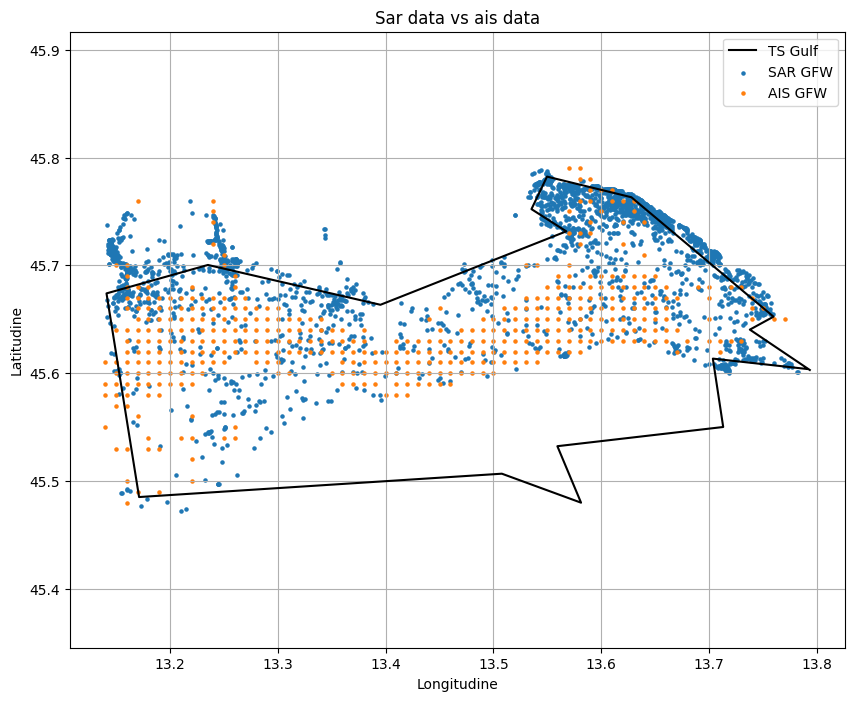

In [6]:
plt.figure(figsize=(10,8))

plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(sar_unq_coords['longitude'], sar_unq_coords['latitude'], label = 'SAR GFW', s = 5)
plt.scatter(ais_unq_coords['longitude'], ais_unq_coords['latitude'], label = 'AIS GFW', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.title("Sar data vs ais data")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

In [7]:
trawlers_condition = ais['gear_type'] == 'TRAWLERS'
pots_and_traps_condition = ais['gear_type'] == 'POTS_AND_TRAPS'
dredge_fishing_condition = ais['gear_type'] == 'DREDGE_FISHING'
other_purse_seines_condition = ais['gear_type'] == 'OTHER_PURSE_SEINES'
fishing_condition = ais['gear_type'] == 'FISHING'   

ais_trawlers = ais[trawlers_condition].copy()
ais_n_trawlers = ais[~trawlers_condition].copy()
ais_pots_and_traps = ais[pots_and_traps_condition].copy()
ais_dredge_fishing = ais[dredge_fishing_condition].copy()
ais_other_purse_seines = ais[other_purse_seines_condition].copy()
ais_fishing = ais[fishing_condition].copy()


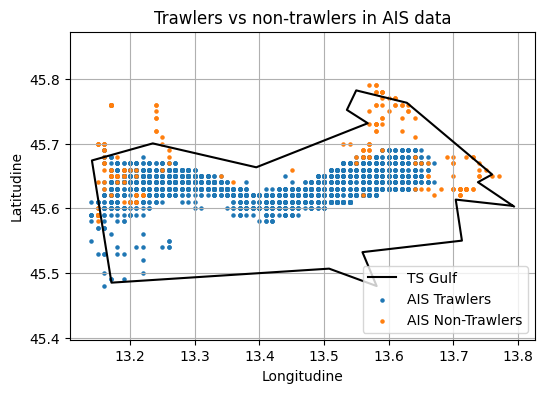

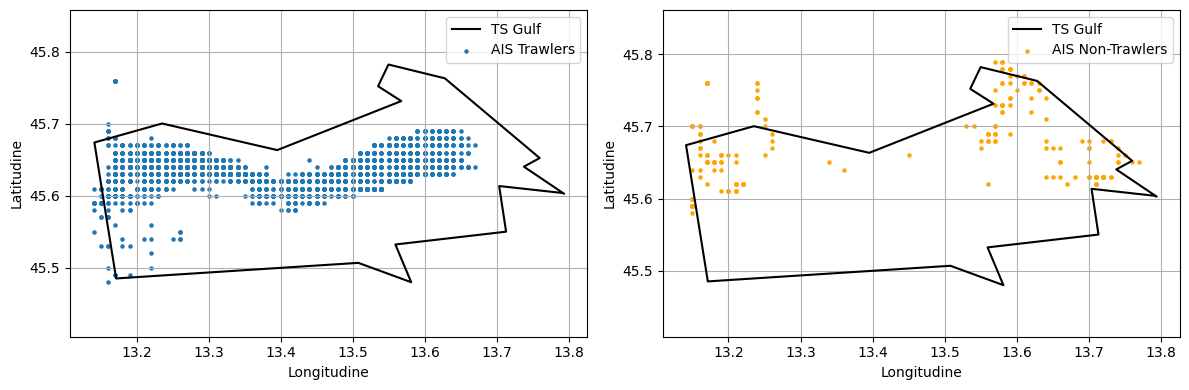

In [8]:
plt.figure(figsize=(6,4))

plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], label = 'AIS Trawlers', s = 5)
plt.scatter(ais_n_trawlers['longitude'], ais_n_trawlers['latitude'], label = 'AIS Non-Trawlers', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.title("Trawlers vs non-trawlers in AIS data")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Primo subplot: Trawlers ---
axes[0].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[0].scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], s=5, label='AIS Trawlers')
axes[0].set_xlim(13, 14)
axes[0].set_ylim(45.3, 45.9)
axes[0].set_xlabel("Longitudine")
axes[0].set_ylabel("Latitudine")
axes[0].grid(True)
axes[0].axis("equal")
axes[0].legend()

# --- Secondo subplot: Non-Trawlers ---
axes[1].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[1].scatter(ais_n_trawlers['longitude'], ais_n_trawlers['latitude'], s=5, color='orange', label='AIS Non-Trawlers')
axes[1].set_xlim(13, 14)
axes[1].set_ylim(45.3, 45.9)
axes[1].set_xlabel("Longitudine")
axes[1].set_ylabel("Latitudine")
axes[1].grid(True)
axes[1].axis("equal")
axes[1].legend()

plt.tight_layout()
plt.show()


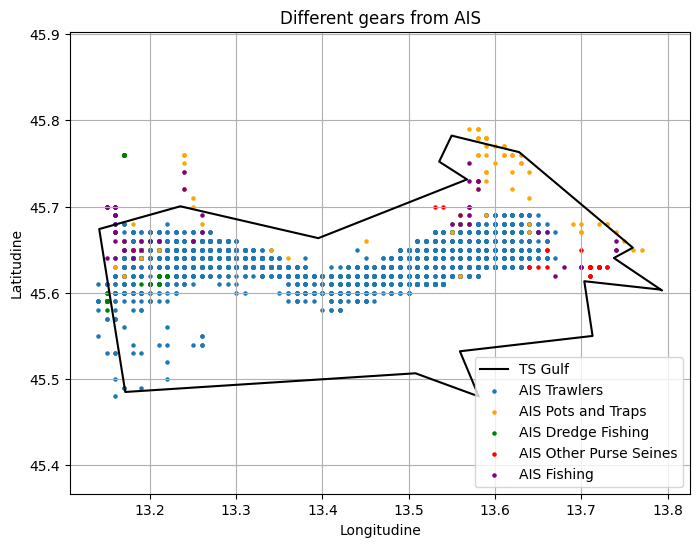

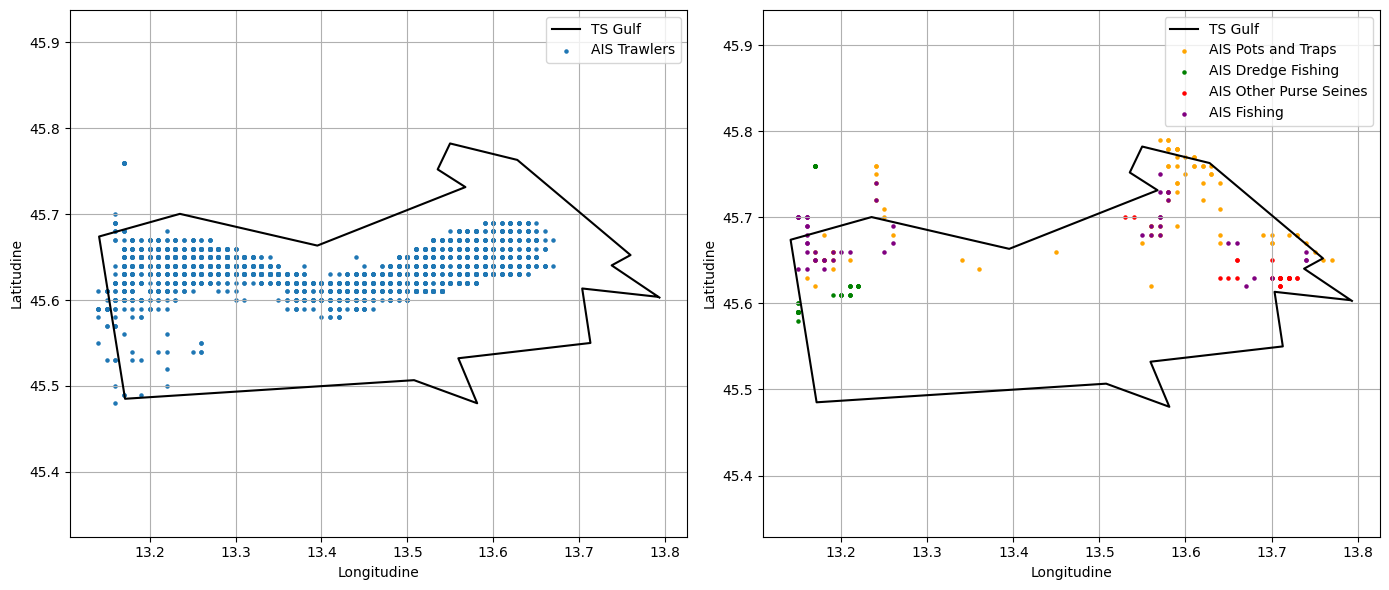

In [9]:
plt.figure(figsize=(8,6))

plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], label = 'AIS Trawlers', s = 5)
plt.scatter(ais_pots_and_traps['longitude'], ais_pots_and_traps['latitude'], label = 'AIS Pots and Traps', s = 5, color = 'orange')
plt.scatter(ais_dredge_fishing['longitude'], ais_dredge_fishing['latitude'], label = 'AIS Dredge Fishing', s = 5, color = 'green')
plt.scatter(ais_other_purse_seines['longitude'], ais_other_purse_seines['latitude'], label = 'AIS Other Purse Seines', s = 5, color = 'red')
plt.scatter(ais_fishing['longitude'], ais_fishing['latitude'], label = 'AIS Fishing', s = 5, color = 'purple')
plt.title("Different gears from AIS")
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------------
# SUBPLOT 1 — AIS Trawlers
# -------------------------------
axes[0].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[0].scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], s=5, label='AIS Trawlers')

axes[0].set_xlim(13, 14)
axes[0].set_ylim(45.3, 45.9)
axes[0].set_xlabel("Longitudine")
axes[0].set_ylabel("Latitudine")
axes[0].grid(True)
axes[0].axis("equal")
axes[0].legend()


# -------------------------------
# SUBPLOT 2 — Altri attrezzi (Pots, Dredge, Purse Seines, Fishing)
# -------------------------------
axes[1].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[1].scatter(ais_pots_and_traps['longitude'], ais_pots_and_traps['latitude'], s=5, label='AIS Pots and Traps', color='orange')
axes[1].scatter(ais_dredge_fishing['longitude'], ais_dredge_fishing['latitude'], s=5, label='AIS Dredge Fishing', color='green')
axes[1].scatter(ais_other_purse_seines['longitude'], ais_other_purse_seines['latitude'], s=5, label='AIS Other Purse Seines', color='red')
axes[1].scatter(ais_fishing['longitude'], ais_fishing['latitude'], s=5, label='AIS Fishing', color='purple')

axes[1].set_xlim(13, 14)
axes[1].set_ylim(45.3, 45.9)
axes[1].set_xlabel("Longitudine")
axes[1].set_ylabel("Latitudine")
axes[1].grid(True)
axes[1].axis("equal")
axes[1].legend()


plt.tight_layout()
plt.show()


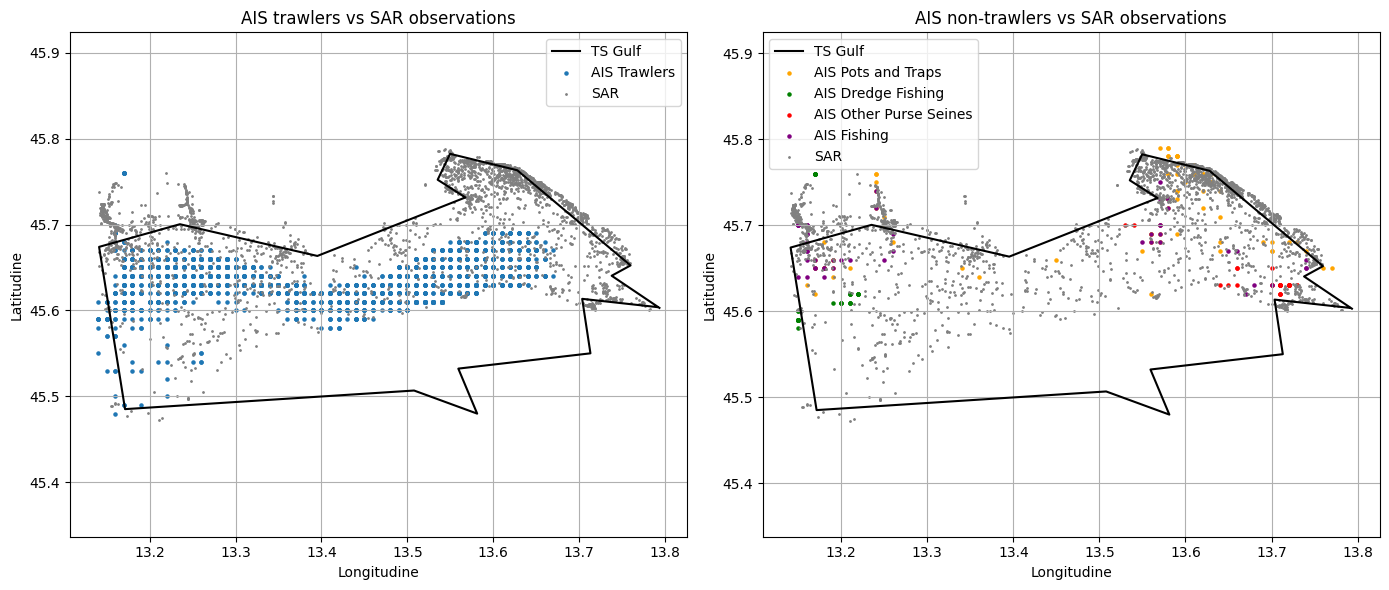

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------------
# SUBPLOT 1 — AIS Trawlers
# -------------------------------
axes[0].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[0].scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], s=5, label='AIS Trawlers')
axes[0].scatter(sar['longitude'], sar['latitude'], s=1, label='SAR', color = 'grey')

axes[0].set_title("AIS trawlers vs SAR observations")
axes[0].set_xlim(13, 14)
axes[0].set_ylim(45.3, 45.9)
axes[0].set_xlabel("Longitudine")
axes[0].set_ylabel("Latitudine")
axes[0].grid(True)
axes[0].axis("equal")
axes[0].legend()


# -------------------------------
# SUBPLOT 2 — Altri attrezzi (Pots, Dredge, Purse Seines, Fishing)
# -------------------------------
axes[1].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[1].scatter(ais_pots_and_traps['longitude'], ais_pots_and_traps['latitude'], s=5, label='AIS Pots and Traps', color='orange')
axes[1].scatter(ais_dredge_fishing['longitude'], ais_dredge_fishing['latitude'], s=5, label='AIS Dredge Fishing', color='green')
axes[1].scatter(ais_other_purse_seines['longitude'], ais_other_purse_seines['latitude'], s=5, label='AIS Other Purse Seines', color='red')
axes[1].scatter(ais_fishing['longitude'], ais_fishing['latitude'], s=5, label='AIS Fishing', color='purple')
axes[1].scatter(sar['longitude'], sar['latitude'], s=1, label='SAR', color = 'grey')

axes[1].set_title("AIS non-trawlers vs SAR observations")
axes[1].set_xlim(13, 14)
axes[1].set_ylim(45.3, 45.9)
axes[1].set_xlabel("Longitudine")
axes[1].set_ylabel("Latitudine")
axes[1].grid(True)
axes[1].axis("equal")
axes[1].legend()


plt.tight_layout()
plt.show()

# Day by day - spatial analysis 

In [13]:
import math
import pandas as pd
import matplotlib.pyplot as plt


def plot_daily_detection_maps(
    ais=None,
    sar=None,
    gulf_coords=None,
    start_date="2024-12-01",
    end_date="2024-12-10",
    source="ais",  # "ais", "sar", or "both"
    ais_date_col="date",
    sar_date_col="date",
    lon_col="longitude",
    lat_col="latitude",
    xlim=(13, 14),
    ylim=(45.3, 45.9),
    ncols=5,
    point_size=8,
):
    """
    Plot daily AIS/SAR detections on the Gulf of Trieste map.

    Parameters
    ----------
    ais:
        AIS dataframe.
    sar:
        SAR/Sentinel dataframe.
    gulf_coords:
        DataFrame with Gulf boundary coordinates.
    start_date, end_date:
        Date range to plot.
    source:
        "ais", "sar", or "both".
    ais_date_col, sar_date_col:
        Date column names for AIS and SAR datasets.
    """

    if source not in ["ais", "sar", "both"]:
        raise ValueError("source must be one of: 'ais', 'sar', 'both'")

    if source in ["ais", "both"] and ais is None:
        raise ValueError("AIS dataframe must be provided when source is 'ais' or 'both'.")

    if source in ["sar", "both"] and sar is None:
        raise ValueError("SAR dataframe must be provided when source is 'sar' or 'both'.")

    if gulf_coords is None:
        raise ValueError("gulf_coords must be provided.")

    start_date = pd.to_datetime(start_date).normalize()
    end_date = pd.to_datetime(end_date).normalize()
    dates = pd.date_range(start_date, end_date, freq="D")

    ais_plot = None
    sar_plot = None

    if ais is not None:
        ais_plot = ais.copy()
        ais_plot[ais_date_col] = pd.to_datetime(ais_plot[ais_date_col]).dt.normalize()

    if sar is not None:
        sar_plot = sar.copy()
        sar_plot[sar_date_col] = pd.to_datetime(sar_plot[sar_date_col]).dt.normalize()

    n_days = len(dates)
    nrows = math.ceil(n_days / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4 * ncols, 4 * nrows),
        squeeze=False,
    )

    axes_flat = axes.ravel()

    for ax, current_date in zip(axes_flat, dates):

        ax.plot(
            gulf_coords[lon_col],
            gulf_coords[lat_col],
            color="black",
            linewidth=1,
            label="TS Gulf",
        )

        if source in ["ais", "both"]:
            ais_day = ais_plot[ais_plot[ais_date_col] == current_date]

            ax.scatter(
                ais_day[lon_col],
                ais_day[lat_col],
                s=point_size,
                alpha=0.8,
                label=f"AIS ({len(ais_day)})",
            )

        if source in ["sar", "both"]:
            sar_day = sar_plot[sar_plot[sar_date_col] == current_date]

            ax.scatter(
                sar_day[lon_col],
                sar_day[lat_col],
                s=point_size,
                alpha=0.8,
                marker="x",
                label=f"SAR ({len(sar_day)})",
            )

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_title(current_date.strftime("%Y-%m-%d"))
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True, alpha=0.3)
        ax.axis("equal")
        ax.legend(fontsize=8)

    for ax in axes_flat[n_days:]:
        ax.axis("off")

    fig.suptitle(
        f"{source.upper()} detections from {start_date.date()} to {end_date.date()}",
        fontsize=16,
    )

    fig.tight_layout()
    plt.show()

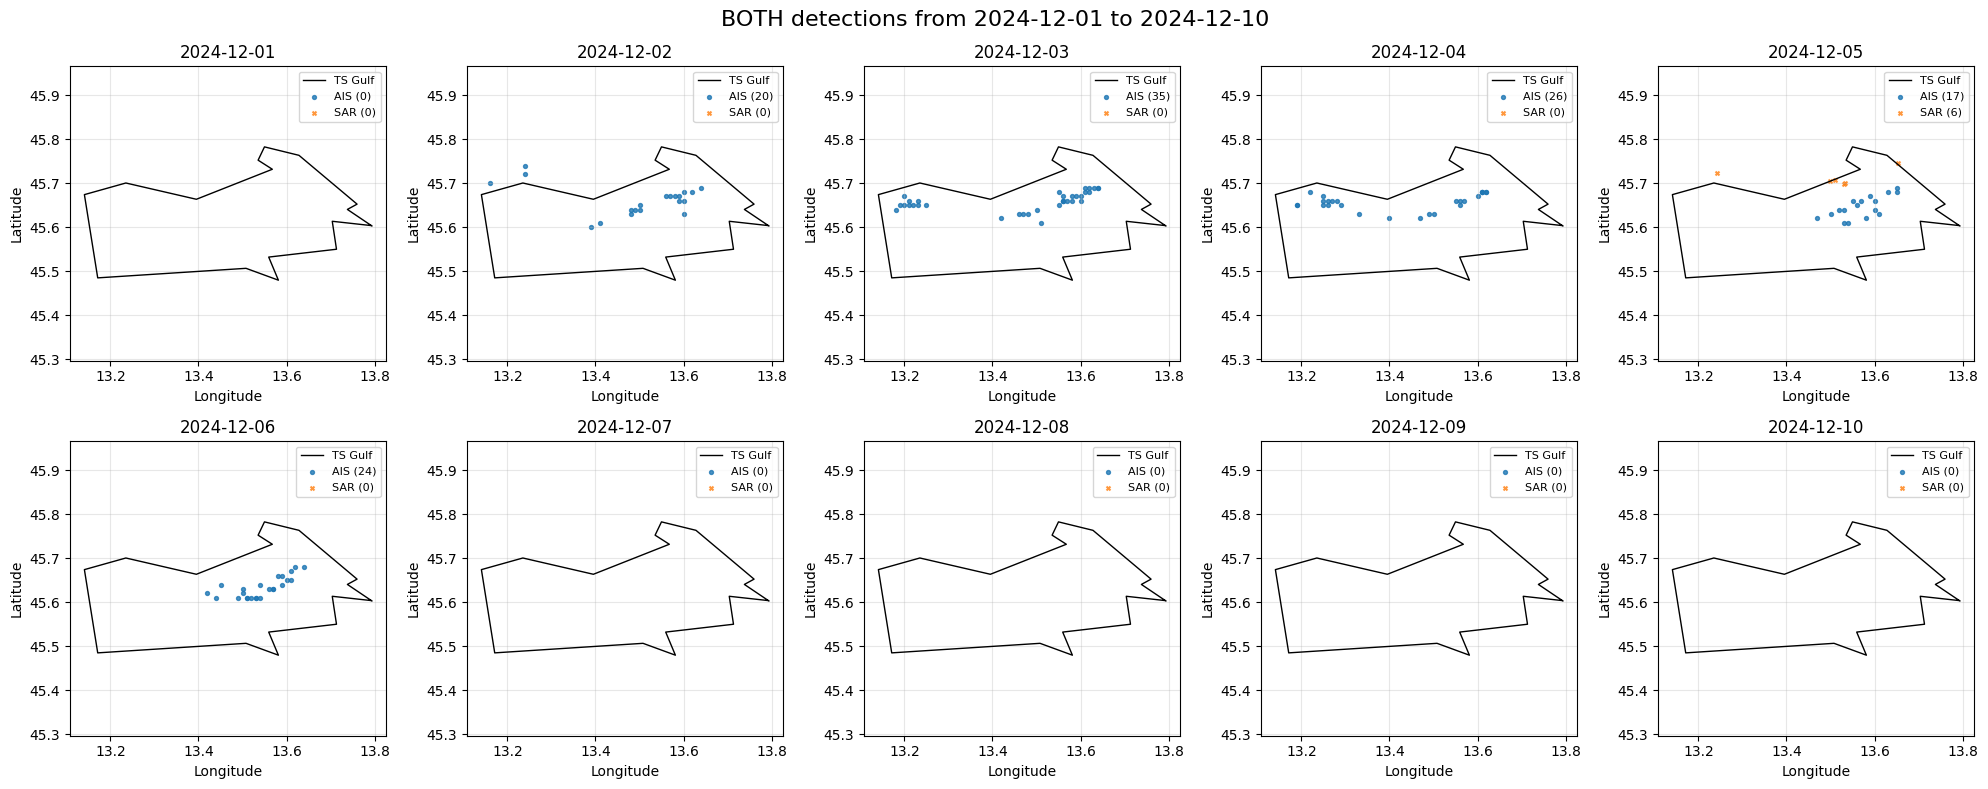

In [22]:
plot_daily_detection_maps(
    ais=ais,
    sar=sar,
    gulf_coords=gulf_coords,
    start_date="2024-12-01",
    end_date="2024-12-10",
    source="both", # ais OR sar OR both
)

# Marine variables - spatial analysis 

In [ ]:
cpr_gfw.head()

,date,is_holiday,holiday_name,is_weekend,fishing_block,latitude,longitude,chl,thetao,sar_vessels_count,ais_vessels_count,DREDGE_FISHING,FISHING,OTHER_PURSE_SEINES,POTS_AND_TRAPS,TRAWLERS
0,2024-01-01,True,New Year's Day,False,False,45.479168,13.166667,0.377122,13.599393,0,0,0,0,0,0,0
1,2024-01-01,True,New Year's Day,False,False,45.479168,13.208333,0.376546,13.613258,0,0,0,0,0,0,0
2,2024-01-01,True,New Year's Day,False,False,45.520832,13.166667,0.367301,13.350998,0,0,0,0,0,0,0
3,2024-01-01,True,New Year's Day,False,False,45.520832,13.208333,0.367821,13.401310,0,0,0,0,0,0,0
4,2024-01-01,True,New Year's Day,False,False,45.520832,13.250000,0.368139,13.423026,0,0,0,0,0,0,0


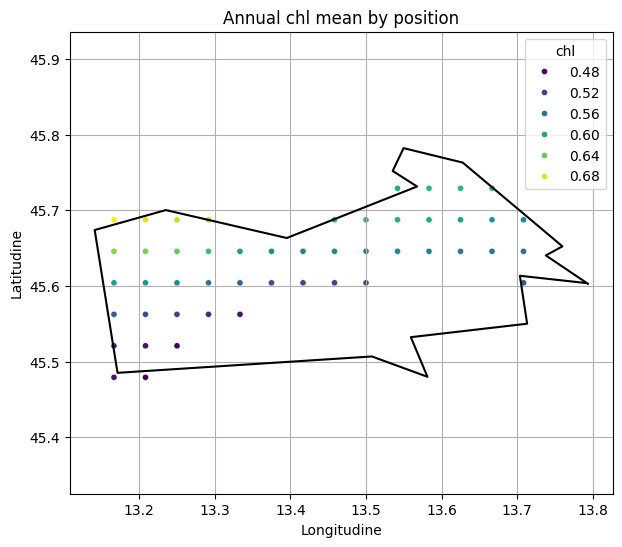

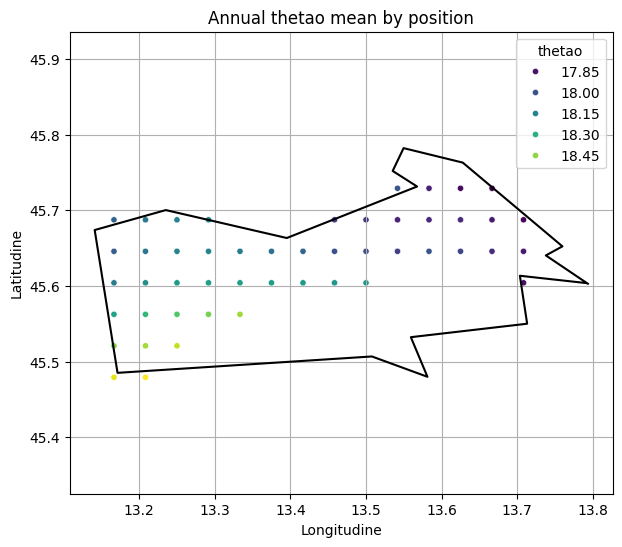

In [ ]:
bgc_var_names = ['chl', 'thetao']  # chl, thetao

for bgc_var_name in bgc_var_names:
    df_pos = cpr_gfw.groupby(["latitude", "longitude"], as_index=False)[bgc_var_name].mean()

    plt.figure(figsize=(7, 6))
    
    sns.scatterplot(
        data=df_pos,
        x="longitude",
        y="latitude",
        hue=bgc_var_name,
        palette="viridis",
        s=20
    )
    plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], color = 'black')
    
    plt.xlabel("Longitudine")
    plt.ylabel("Latitudine")
    plt.title(f"Annual {bgc_var_name} mean by position")
    plt.axis("equal")
    plt.grid(True)
    
    plt.show()


# Marine variables - temporal analysis 

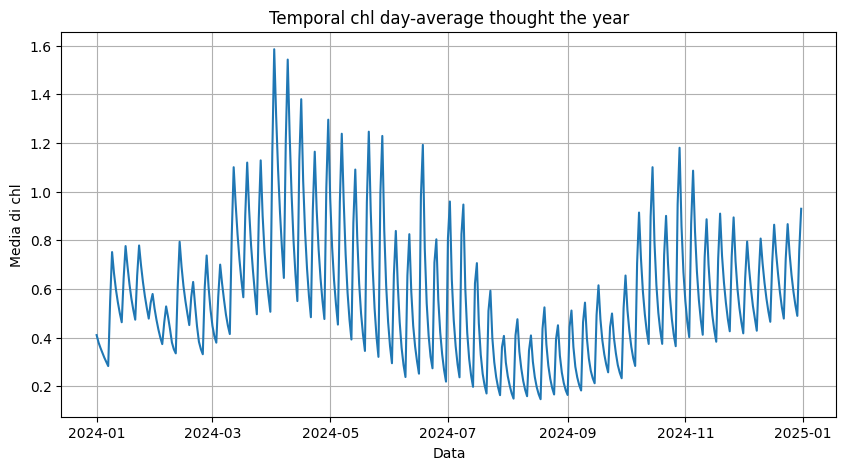

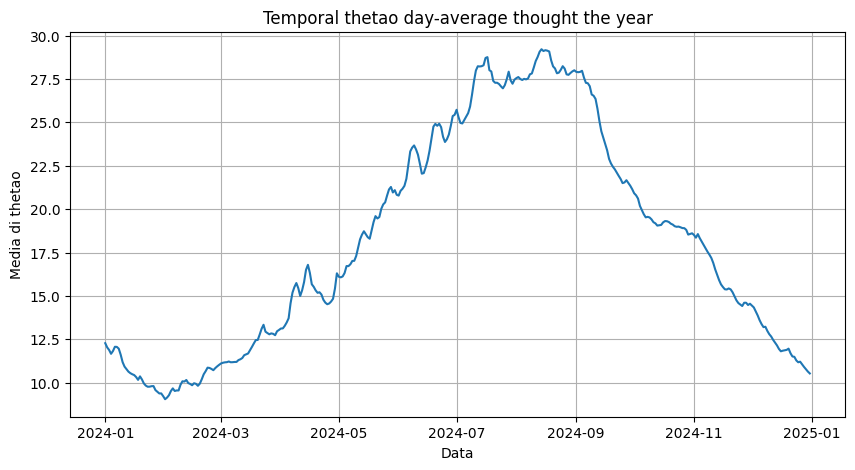

In [ ]:
bgc_var_names = ['chl', 'thetao']  # chl, thetao

for bgc_var_name in bgc_var_names:
    df_bgc = cpr_gfw.groupby('date', as_index=False)[bgc_var_name].mean()
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_bgc['date'], df_bgc[bgc_var_name])
    plt.xlabel('Data')
    plt.ylabel(f'Media di {bgc_var_name}')
    plt.title(f'Temporal {bgc_var_name} day-average thought the year')
    plt.grid(True)
    plt.show()

# Gears - temporal analysis 

In [ ]:
cpr_gfw.columns

Index(['date', 'is_holiday', 'holiday_name', 'is_weekend', 'fishing_block',
       'latitude', 'longitude', 'chl', 'thetao', 'sar_vessels_count',
       'ais_vessels_count', 'DREDGE_FISHING', 'FISHING', 'OTHER_PURSE_SEINES',
       'POTS_AND_TRAPS', 'TRAWLERS'],
      dtype='object')

In [ ]:
import numpy as np

# Riassumo per data le info di weekend/festivo (max va bene per bool)
date_flags = (
    cpr_gfw
    .groupby('date', as_index=False)[['is_weekend', 'is_holiday']]
    .max()
)


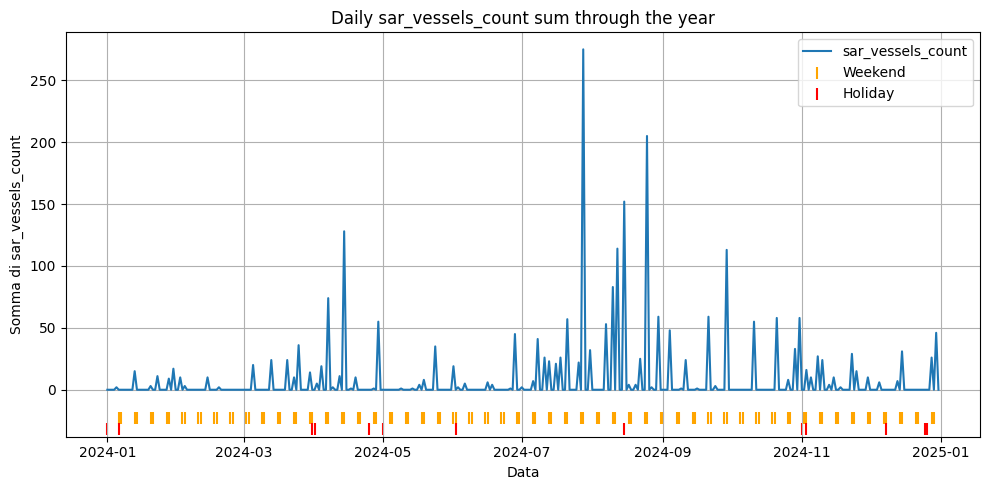

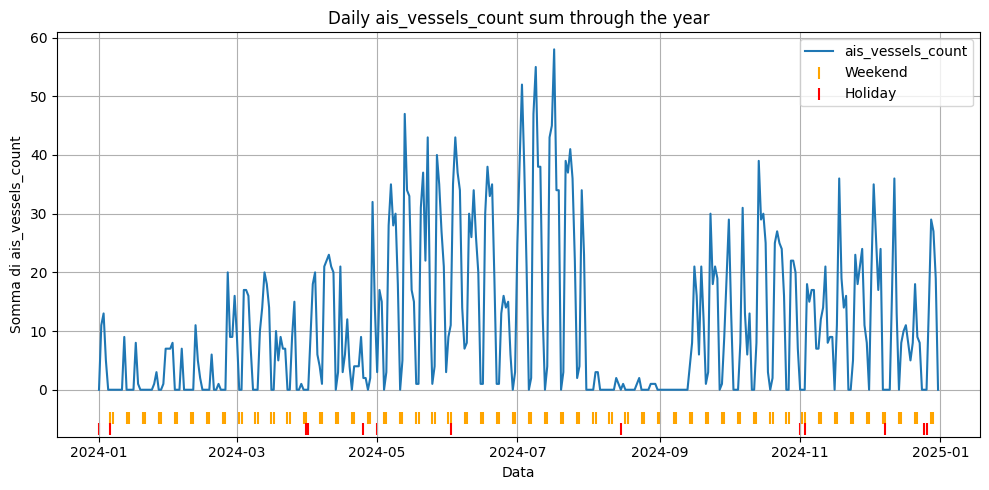

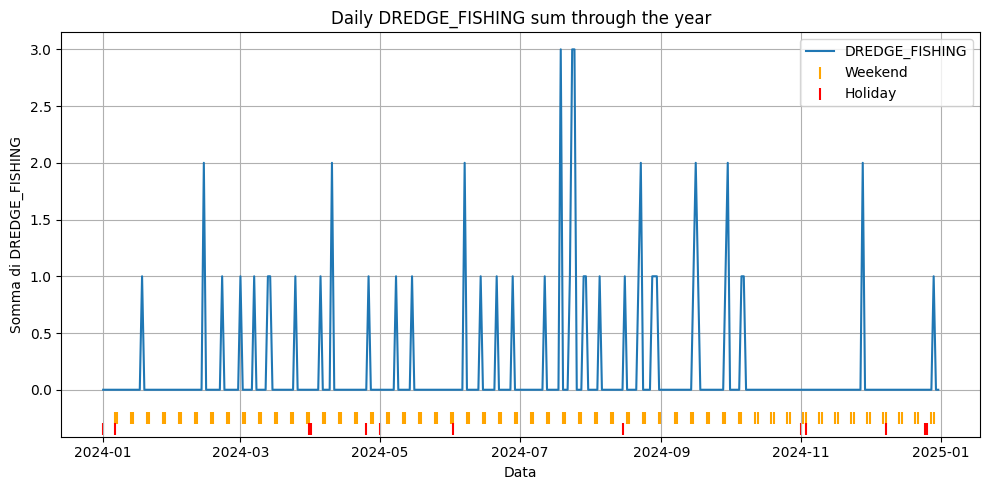

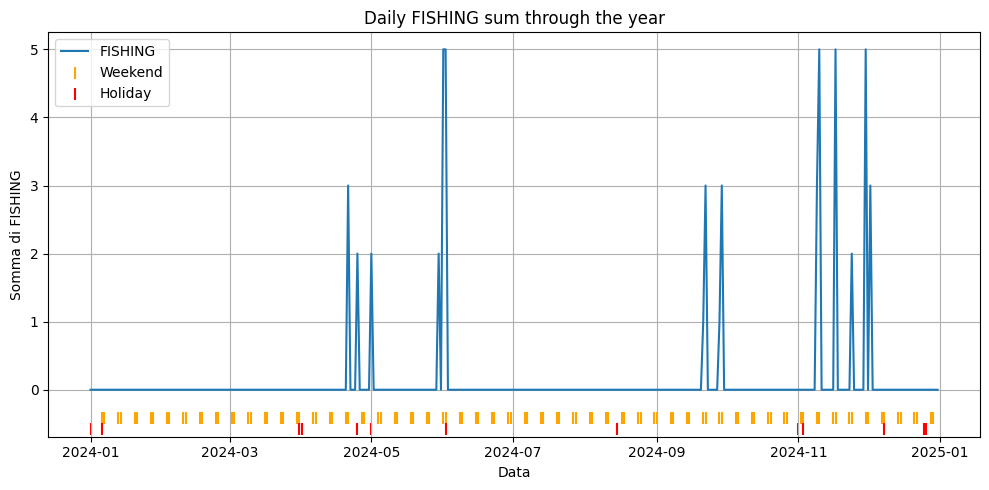

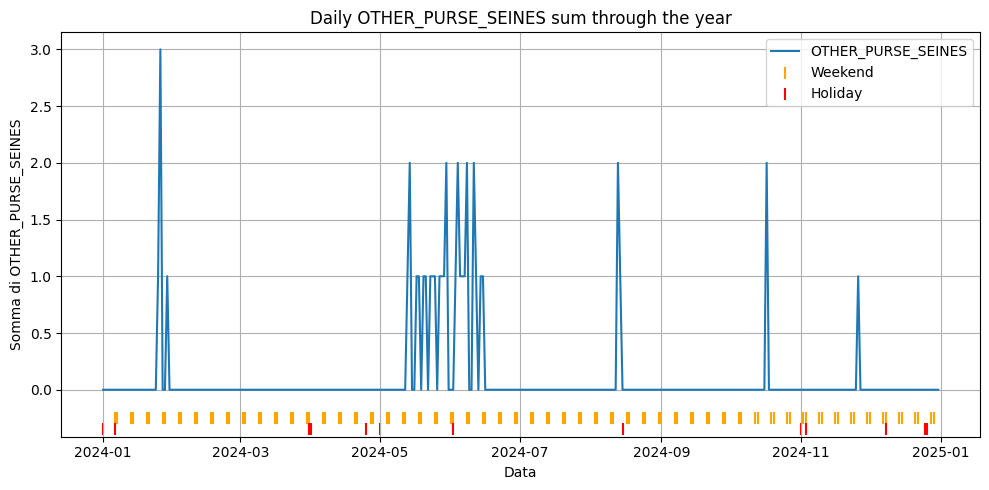

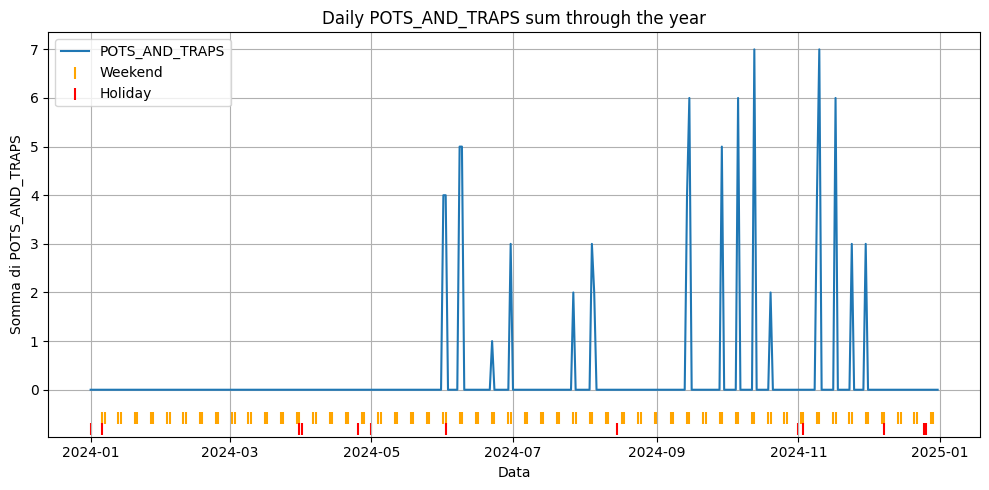

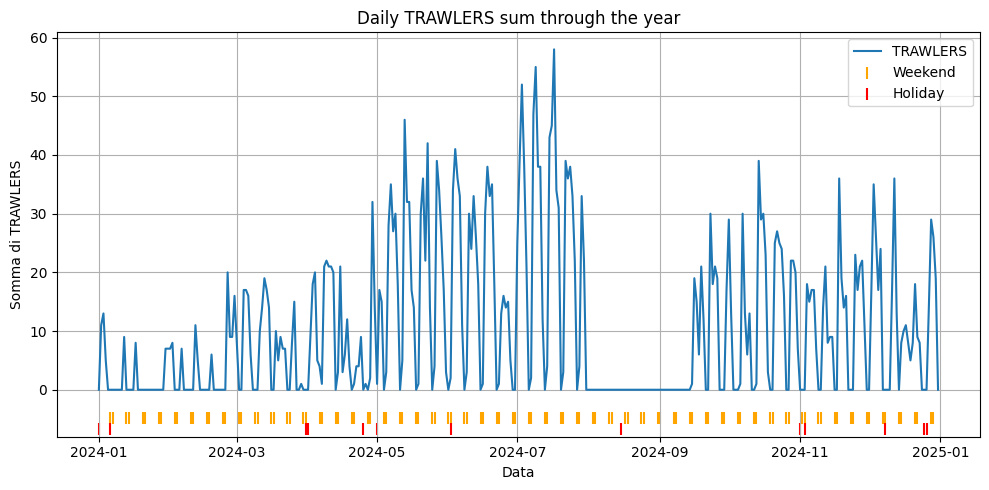

In [ ]:
vessel_vars = [ 'sar_vessels_count', 'ais_vessels_count',
       'DREDGE_FISHING', 'FISHING', 'OTHER_PURSE_SEINES', 'POTS_AND_TRAPS',
       'TRAWLERS']  

for vessel_var in vessel_vars:
    # somma giornaliera
    df_bgc = cpr_gfw.groupby('date', as_index=False)[vessel_var].sum()
    # aggiungo info weekend/festivi
    df_plot = df_bgc.merge(date_flags, on='date', how='left')
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # linea principale
    ax.plot(df_plot['date'], df_plot[vessel_var], label=vessel_var)
    ax.set_xlabel('Data')
    ax.set_ylabel(f'Somma di {vessel_var}')
    ax.set_title(f'Daily {vessel_var} sum through the year')
    ax.grid(True)

    # prendo i limiti attuali
    ymin, ymax = ax.get_ylim()
    span = ymax - ymin if ymax > ymin else 1.0

    # livelli leggermente sotto la serie per i marker
    y_weekend = ymin - 0.03 * span
    y_holiday = ymin - 0.06 * span

    # aggiusto il limite inferiore per farli vedere
    ax.set_ylim(y_holiday - 0.02 * span, ymax)

    # weekend: piccoli segmenti verticali (marker '|')
    weekend_dates = df_plot.loc[df_plot['is_weekend'], 'date']
    ax.scatter(
        weekend_dates,
        np.full(len(weekend_dates), y_weekend),
        marker='|',
        color='orange',
        s=80,
        label='Weekend'
    )

    # festività: piccoli segmenti verticali (marker '|')
    holiday_dates = df_plot.loc[df_plot['is_holiday'], 'date']
    ax.scatter(
        holiday_dates,
        np.full(len(holiday_dates), y_holiday),
        marker='|',
        color='red',
        s=80,
        label='Holiday'
    )

    # legenda (evito doppioni)
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys())

    plt.tight_layout()
    plt.show()


In [ ]:
print("Medie delle variabili di vessel count nei giorni festivi:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['is_holiday'] == True
    ][vessel_var].mean()
    )

print("\nMedie delle variabili di vessel count nei giorni NON festivi:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['is_holiday'] == False
    ][vessel_var].mean()
    )

print("\nMedie delle variabili di vessel count nei weekend:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['is_weekend'] == True
    ][vessel_var].mean()
    )

print("\nMedie delle variabili di vessel count nei giorni infrasettimanali:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['is_weekend'] == False
    ][vessel_var].mean()
    )

print("\nMedie delle variabili di vessel count nei giorni di blocco pesca:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['fishing_block'] == True
    ][vessel_var].mean()
    )


print("\nMedie delle variabili di vessel count nei giorni senza blocco pesca:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['fishing_block'] == False
    ][vessel_var].mean()
    )



Medie delle variabili di vessel count nei giorni festivi:
sar_vessels_count 0.26373626373626374
ais_vessels_count 0.02511773940345369
DREDGE_FISHING 0.0
FISHING 0.0141287284144427
OTHER_PURSE_SEINES 0.0
POTS_AND_TRAPS 0.006279434850863423
TRAWLERS 0.004709576138147566

Medie delle variabili di vessel count nei giorni NON festivi:
sar_vessels_count 0.14083367057871307
ais_vessels_count 0.23258368503208648
DREDGE_FISHING 0.0030641151644793894
FISHING 0.0023703532404463204
OTHER_PURSE_SEINES 0.0022547262531074754
POTS_AND_TRAPS 0.004509452506214951
TRAWLERS 0.22038503786783836

Medie delle variabili di vessel count nei weekend:
sar_vessels_count 0.24725274725274726
ais_vessels_count 0.05239403453689168
DREDGE_FISHING 0.0007849293563579278
FISHING 0.00804552590266876
OTHER_PURSE_SEINES 0.0009811616954474097
POTS_AND_TRAPS 0.015698587127158554
TRAWLERS 0.026883830455259026

Medie delle variabili di vessel count nei giorni infrasettimanali:
sar_vessels_count 0.10468920392584515
ais_vessels_c

In [ ]:
cpr_gfw.head()

,date,is_holiday,holiday_name,is_weekend,fishing_block,latitude,longitude,chl,thetao,sar_vessels_count,ais_vessels_count,DREDGE_FISHING,FISHING,OTHER_PURSE_SEINES,POTS_AND_TRAPS,TRAWLERS
0,2024-01-01,True,New Year's Day,False,False,45.479168,13.166667,0.377122,13.599393,0,0,0,0,0,0,0
1,2024-01-01,True,New Year's Day,False,False,45.479168,13.208333,0.376546,13.613258,0,0,0,0,0,0,0
2,2024-01-01,True,New Year's Day,False,False,45.520832,13.166667,0.367301,13.350998,0,0,0,0,0,0,0
3,2024-01-01,True,New Year's Day,False,False,45.520832,13.208333,0.367821,13.401310,0,0,0,0,0,0,0
4,2024-01-01,True,New Year's Day,False,False,45.520832,13.250000,0.368139,13.423026,0,0,0,0,0,0,0
